# Harmonisasi & Pengambilan Irisan 7 Kelas (Standar Emas Medis Dunia)
## Penggabungan Terkurasi HAM10000 ∩ ISIC 2019

Notebook ini mengimplementasikan alur **Jalur Irisan 7 Kelas** sesuai rancangan riset dan konsensus ilmiah internasional.
Dengan menggabungkan **HAM10000** (10.015 citra) dan **ISIC 2019** (25.331 citra), kita membentuk dataset multiclass terstandarisasi dengan **7 kelas diagnosis standar emas** yang mencakup >95% seluruh lesi kulit berpigmen di dunia klinis.

### Rujukan Ilmiah Utama:
1. **Baig et al. (MDPI Diagnostics 2023):** Formulasi tepat 7 kelas multiclass dari gabungan HAM10k + ISIC 2019 (`AK`, `BCC`, `BKL`, `DF`, `NV`, `MEL`, `VASC`).
2. **Ichim et al. (MDPI Cancers 2023):** Protokol eliminasi duplikasi citra lesi antar-arsip ISIC (*overlap removal*).
3. **Tschandl et al. (Nature Scientific Data 2018):** Taksonomi medis dan bukti klinis 7 kelas representasi lesi berpigmen.
4. **Rahman et al. (Wiley CAAI Trans 2025):** Analisis komparatif sebaran fitur dan penanganan ketimpangan kelas minoritas (`DF` & `VASC`).


## Langkah 1 — Setup Library, Konfigurasi Path, & Dataset Sumber
Menyiapkan modul Python, mendeteksi lokasi direktori dataset secara adaptif, dan mendefinisikan sumber data (HAM10000 dan ISIC 2019 Training Input).


In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# Deteksi root folder dataset secara adaptif
folder_aktif = os.getcwd()
if os.path.exists(os.path.join(folder_aktif, 'Dataset')):
    ROOT = os.path.join(folder_aktif, 'Dataset')
elif os.path.exists(os.path.join(os.path.dirname(folder_aktif), 'Dataset')):
    ROOT = os.path.join(os.path.dirname(folder_aktif), 'Dataset')
else:
    ROOT = r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"

print(f"Folder Dataset Aktif: {ROOT}")

# Konfigurasi 2 Dataset Sumber
SOURCES = {
    'ham10000': {
        'nama': 'HAM10000 (ViDIR Austria & Queensland Australia)',
        'year': '2018',
        'gt_format': 'ham_dx',
        'img_dirs': [
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_1'),
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_2'),
        ],
        'gt_path': os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'),
    },
    'isic_2019_train': {
        'nama': 'ISIC 2019 Training Data (BCN-20000 + ViDIR + HAM10k Overlap)',
        'year': '2019',
        'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Metadata.csv'),
    }
}

for k, v in SOURCES.items():
    print(f"[*] {k}: {v['nama']}")


Folder Dataset Aktif: C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset
[*] ham10000: HAM10000 (ViDIR Austria & Queensland Australia)
[*] isic_2019_train: ISIC 2019 Training Data (BCN-20000 + ViDIR + HAM10k Overlap)


## Langkah 2 — Pemindaian Citra Fisik & Ground Truth Asli
Memindai seluruh file citra fisik (.jpg) pada media penyimpanan serta mengekstraksi ground truth asli masing-masing dataset secara terpisah untuk menjaga keaslian label asal.


In [2]:
# 1. Pindai seluruh citra fisik
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(d, f)
                        })
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(root_dir, f)
                        })

df_images = pd.DataFrame(all_images)

# 2. Muat Ground Truth masing-masing sumber secara independen (menghindari kontaminasi key overlap)
gt_records = {}

# HAM10000
df_gt_ham = pd.read_csv(SOURCES['ham10000']['gt_path'])
ham_label_map = dict(zip(df_gt_ham['image_id'], df_gt_ham['dx'].str.lower()))
gt_records['ham10000'] = ham_label_map

# ISIC 2019
df_gt_19 = pd.read_csv(SOURCES['isic_2019_train']['gt_path'])
cols_19 = [c for c in df_gt_19.columns if c not in ('image', 'score_weight', 'validation_weight')]
isic19_label_map = {}
for _, row in df_gt_19.iterrows():
    assigned = None
    for c in cols_19:
        if row[c] == 1.0:
            assigned = c.lower()
            break
    if assigned:
        isic19_label_map[row['image']] = assigned
gt_records['isic_2019_train'] = isic19_label_map

# Pasangkan label sesuai (source, image_id)
def get_original_label(row):
    src = row['source']
    img_id = row['image_id']
    return gt_records.get(src, {}).get(img_id, np.nan)

df_images['original_label'] = df_images.apply(get_original_label, axis=1)

print(f"Total citra fisik terindeks dari 2 sumber: {len(df_images):,} citra")
for src in SOURCES.keys():
    sub = df_images[df_images['source'] == src]
    print(f"  - {src}: {len(sub):,} citra fisik ({sub['original_label'].notna().sum():,} memiliki ground truth)")


Total citra fisik terindeks dari 2 sumber: 35,346 citra
  - ham10000: 10,015 citra fisik (10,015 memiliki ground truth)
  - isic_2019_train: 25,331 citra fisik (25,331 memiliki ground truth)


## Langkah 3 — Deduplikasi Terarah (HAM10000 Prioritas 100% Utuh)
Sesuai protokol *overlap removal* (Ichim et al., 2023), seluruh citra HAM10000 dipertahankan 100% utuh (10.015 citra).
Citra pada ISIC 2019 yang merupakan duplikasi identik dari HAM10000 dieliminasi, sehingga hanya citra baru yang unik dari ISIC 2019 yang diikutsertakan.


In [3]:
PRIORITY_ORDER = ['ham10000', 'isic_2019_train']
priority_rank = {src: i for i, src in enumerate(PRIORITY_ORDER)}

df_all = df_images.copy()
df_all['priority'] = df_all['source'].map(priority_rank)

# Urutkan berdasarkan prioritas dan buang duplikat image_id
df_sorted = df_all.sort_values(by=['image_id', 'priority'])
df_clean = df_sorted.drop_duplicates(subset='image_id', keep='first').copy()
df_dropped = df_sorted[~df_sorted.index.isin(df_clean.index)].copy()

# Petakan duplikat disimpan di mana
kept_map = df_clean.set_index('image_id')['source'].to_dict()
df_dropped['kept_in_source'] = df_dropped['image_id'].map(kept_map)

# Tabel Before vs After Deduplikasi
before_counts = df_all['source'].value_counts()
after_counts = df_clean['source'].value_counts()
dropped_counts = df_dropped['source'].value_counts()

rows_ba = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    d = dropped_counts.get(src, 0)
    pct_drop = round((d / b * 100), 2) if b > 0 else 0
    
    dropped_src = df_dropped[df_dropped['source'] == src]
    if len(dropped_src) > 0:
        kept_counts = dropped_src['kept_in_source'].value_counts()
        detail_kept = "; ".join([f"{k} ({v:,} citra)" for k, v in kept_counts.items()])
    else:
        detail_kept = "-"
        
    rows_ba.append({
        'Source Dataset': src,
        'Before (Awal)': f"{b:,}",
        'Duplikat Dihapus': f"{d:,}",
        'After (Bersih Unik)': f"{a:,}",
        '% Reduksi': f"{pct_drop}%",
        'Keterangan Deduplikasi': detail_kept
    })

df_ba_table = pd.DataFrame(rows_ba)
print("=== TABEL BEFORE vs AFTER DEDUPLIKASI (HAM10000 DIPERTAHANKAN 100%) ===")
display(df_ba_table)

print(f"\nTotal citra awal             : {len(df_all):,} citra")
print(f"Total duplikat tumpang tindih: {len(df_dropped):,} citra (100% berasal dari overlap ISIC 2019 vs HAM10k)")
print(f"Total citra unik gabungan    : {len(df_clean):,} citra")


=== TABEL BEFORE vs AFTER DEDUPLIKASI (HAM10000 DIPERTAHANKAN 100%) ===


,Source Dataset,Before (Awal),Duplikat Dihapus,After (Bersih Unik),% Reduksi,Keterangan Deduplikasi
0,ham10000,"10,015",0,"10,015",0.0%,-
1,isic_2019_train,"25,331","10,015","15,316",39.54%,"ham10000 (10,015 citra)"



Total citra awal             : 35,346 citra
Total duplikat tumpang tindih: 10,015 citra (100% berasal dari overlap ISIC 2019 vs HAM10k)
Total citra unik gabungan    : 25,331 citra


## Langkah 4 — Analisis Komparasi Label & Harmonisasi Sinonim Medis
Menyelaraskan kode diagnosis lokal antar-dataset ke dalam kode standar internasional.
Misalnya `ak` pada ISIC 2019 diselaraskan dengan `akiec` pada HAM10000 menjadi kode standar `AKIEC`.


In [4]:
# Matriks harmonisasi sinonim diagnosis medis
HARMONIZATION_MAP = {
    'nv': 'NV',
    'nevus': 'NV',
    'mel': 'MEL',
    'melanoma': 'MEL',
    'bkl': 'BKL',
    'seborrheic_keratosis': 'BKL',
    'bcc': 'BCC',
    'akiec': 'AKIEC',
    'ak': 'AKIEC',
    'vasc': 'VASC',
    'df': 'DF',
    'scc': 'SCC',
    'unk': 'UNK'
}

MED_DESC = {
    'NV': ('Melanocytic Nevus', 'Tahi lalat jinak melanositik'),
    'MEL': ('Melanoma', 'Kanker kulit ganas melanosit'),
    'BCC': ('Basal Cell Carcinoma', 'Karsinoma sel basal ganas'),
    'BKL': ('Benign Keratosis', 'Keratosis seboroik / lentigo surya jinak'),
    'AKIEC': ('Actinic Keratosis / IEC', 'Lesi pra-kanker keratinositik'),
    'VASC': ('Vascular Lesion', 'Kelainan pembuluh darah kulit jinak'),
    'DF': ('Dermatofibroma', 'Nodul jinak jaringan ikat fibrohistiositik'),
    'SCC': ('Squamous Cell Carcinoma', 'Karsinoma sel skuamosa ganas (eksklusif ISIC 2019)'),
    'UNK': ('Unknown / Out of Distribution', 'Di luar kelas terdefinisi')
}

df_clean['harmonized_label'] = df_clean['original_label'].str.lower().map(HARMONIZATION_MAP)

# Ringkasan sebaran label per dataset
harm_summary = []
for code, (med_name, desc) in MED_DESC.items():
    if code == 'UNK':
        continue
    cnt_ham = len(df_clean[(df_clean['source'] == 'ham10000') & (df_clean['harmonized_label'] == code)])
    cnt_19 = len(df_clean[(df_clean['source'] == 'isic_2019_train') & (df_clean['harmonized_label'] == code)])
    tot = cnt_ham + cnt_19
    
    status_irisan = "ADA DI KEDUA DATASET (MASUK IRISAN)" if (cnt_ham > 0 and cnt_19 > 0) else "TIDAK ADA DI HAM10K (GUGUR)"
    harm_summary.append({
        'Kode': code,
        'Nama Diagnosis Medis': med_name,
        'Deskripsi Patologis': desc,
        'HAM10000': f"{cnt_ham:,}",
        'ISIC 2019 (Unik)': f"{cnt_19:,}",
        'Total Gabungan': f"{tot:,}",
        'Status Irisan': status_irisan
    })

df_harm_table = pd.DataFrame(harm_summary)
print("=== TABEL HARMONISASI & STATUS KETERSEDIAAN DI 2 DATASET ===")
display(df_harm_table)


=== TABEL HARMONISASI & STATUS KETERSEDIAAN DI 2 DATASET ===


,Kode,Nama Diagnosis Medis,Deskripsi Patologis,HAM10000,ISIC 2019 (Unik),Total Gabungan,Status Irisan
0,NV,Melanocytic Nevus,Tahi lalat jinak melanositik,"6,705","6,170","12,875",ADA DI KEDUA DATASET (MASUK IRISAN)
1,MEL,Melanoma,Kanker kulit ganas melanosit,"1,113","3,409","4,522",ADA DI KEDUA DATASET (MASUK IRISAN)
2,BCC,Basal Cell Carcinoma,Karsinoma sel basal ganas,514,"2,809","3,323",ADA DI KEDUA DATASET (MASUK IRISAN)
3,BKL,Benign Keratosis,Keratosis seboroik / lentigo surya jinak,"1,099","1,525","2,624",ADA DI KEDUA DATASET (MASUK IRISAN)
4,AKIEC,Actinic Keratosis / IEC,Lesi pra-kanker keratinositik,327,737,"1,064",ADA DI KEDUA DATASET (MASUK IRISAN)
5,VASC,Vascular Lesion,Kelainan pembuluh darah kulit jinak,142,111,253,ADA DI KEDUA DATASET (MASUK IRISAN)
6,DF,Dermatofibroma,Nodul jinak jaringan ikat fibrohistiositik,115,124,239,ADA DI KEDUA DATASET (MASUK IRISAN)
7,SCC,Squamous Cell Carcinoma,Karsinoma sel skuamosa ganas (eksklusif ISIC 2...,0,431,431,TIDAK ADA DI HAM10K (GUGUR)


## Langkah 5 — Pengambilan Irisan (Intersection) 2 Dataset $ightarrow$ 7 Kelas Standar Emas
Sesuai prinsip irisan (*intersection*), kelas yang diambil adalah kelas yang terdefinisi bersama pada kedua dataset (HAM10000 ∩ ISIC 2019).
Hasil persekutuan menghasilkan tepat **7 KELAS STANDAR EMAS** (`NV`, `MEL`, `BCC`, `BKL`, `AKIEC`, `VASC`, `DF`).

Kelas `SCC` (*Squamous Cell Carcinoma*, 431 citra unik baru di ISIC 2019) **gugur secara ilmiah** karena tidak didefinisikan secara independen di HAM10000.


In [5]:
# Himpunan kelas diagnosis
classes_ham = set(df_clean[df_clean['source'] == 'ham10000']['harmonized_label'].unique())
classes_2019 = set(df_clean[df_clean['source'] == 'isic_2019_train']['harmonized_label'].unique())

irisan_7kelas = sorted(list(classes_ham.intersection(classes_2019)))

print("=== HASIL PERHITUNGAN IRISAN KELAS MEDIS ===")
print(f"Kelas pada HAM10000  ({len(classes_ham)} kelas) : {sorted(list(classes_ham))}")
print(f"Kelas pada ISIC 2019 ({len(classes_2019)} kelas) : {sorted(list(classes_2019))}")
print("-" * 75)
print(f"Hasil Irisan Bersama ({len(irisan_7kelas)} kelas) : {irisan_7kelas}")
print(f"Kelas yang Gugur (Hanya di 1 dataset) : {sorted(list(classes_2019 - classes_ham))}")

print(f"\nEvaluasi Alur Riset:")
print(f"  -> Terbentuk Jalur MULTICLASS 7 KELAS STANDAR EMAS: {', '.join(irisan_7kelas)}")


=== HASIL PERHITUNGAN IRISAN KELAS MEDIS ===
Kelas pada HAM10000  (7 kelas) : ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
Kelas pada ISIC 2019 (8 kelas) : ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
---------------------------------------------------------------------------
Hasil Irisan Bersama (7 kelas) : ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
Kelas yang Gugur (Hanya di 1 dataset) : ['SCC']

Evaluasi Alur Riset:
  -> Terbentuk Jalur MULTICLASS 7 KELAS STANDAR EMAS: AKIEC, BCC, BKL, DF, MEL, NV, VASC


## Langkah 6 — Eksekusi Filtering Dataset Irisan & Validasi Integritas Data
Memfilter seluruh data bersih yang hanya memiliki label 7 kelas hasil irisan.
Setiap kelas dipetakan ke ID integer standar benchmark (0–6).


In [6]:
# Filter data hanya pada 7 kelas hasil irisan
df_7kelas_final = df_clean[df_clean['harmonized_label'].isin(irisan_7kelas)].copy()

# Pemetaan ID target standar benchmark (alfabetis sesuai konvensi ISIC 2018 Task 3)
CLASS_MAP = {
    'AKIEC': (0, 'Actinic Keratosis / IEC'),
    'BCC':   (1, 'Basal Cell Carcinoma'),
    'BKL':   (2, 'Benign Keratosis'),
    'DF':    (3, 'Dermatofibroma'),
    'MEL':   (4, 'Melanoma'),
    'NV':    (5, 'Melanocytic Nevus'),
    'VASC':  (6, 'Vascular Lesion')
}

df_7kelas_final['target_7class'] = df_7kelas_final['harmonized_label'].map(lambda x: CLASS_MAP[x][0])
df_7kelas_final['class_name'] = df_7kelas_final['harmonized_label'].map(lambda x: CLASS_MAP[x][1])

# Validasi kuantitatif ketat
total_awal_unik = len(df_clean)
total_gugur_scc = len(df_clean[df_clean['harmonized_label'] == 'SCC'])
total_akhir = len(df_7kelas_final)

print("=== VERIFIKASI VALIDASI INTEGRITAS DATASET IRISAN 7 KELAS ===")
print(f"Total citra unik bersih gabungan : {total_awal_unik:,} citra")
print(f"Citra SCC yang digugurkan        : {total_gugur_scc:,} citra")
print(f"Total citra final 7 kelas        : {total_akhir:,} citra (Target validasi: TEPAT 24.900)")
print(f"Status Missing Values (Null)     : {df_7kelas_final['target_7class'].isna().sum()} (100% Bersih)")
assert total_akhir == 24900, f"Validasi gagal! Jumlah baris adalah {total_akhir}, diharapkan 24.900!"
print(">>> VALIDASI INTEGRITAS 100% SUKSES TEPAT 24.900 CITRA! <<<")

print("\nContoh 10 Baris Pertama Data Final:")
display(df_7kelas_final[['image_id', 'source', 'original_label', 'harmonized_label', 'target_7class', 'class_name']].head(10))


=== VERIFIKASI VALIDASI INTEGRITAS DATASET IRISAN 7 KELAS ===
Total citra unik bersih gabungan : 25,331 citra
Citra SCC yang digugurkan        : 431 citra
Total citra final 7 kelas        : 24,900 citra (Target validasi: TEPAT 24.900)
Status Missing Values (Null)     : 0 (100% Bersih)
>>> VALIDASI INTEGRITAS 100% SUKSES TEPAT 24.900 CITRA! <<<

Contoh 10 Baris Pertama Data Final:


,image_id,source,original_label,harmonized_label,target_7class,class_name
10015,ISIC_0000000,isic_2019_train,nv,NV,5,Melanocytic Nevus
10016,ISIC_0000001,isic_2019_train,nv,NV,5,Melanocytic Nevus
10017,ISIC_0000002,isic_2019_train,mel,MEL,4,Melanoma
10018,ISIC_0000003,isic_2019_train,nv,NV,5,Melanocytic Nevus
10019,ISIC_0000004,isic_2019_train,mel,MEL,4,Melanoma
10020,ISIC_0000006,isic_2019_train,nv,NV,5,Melanocytic Nevus
10021,ISIC_0000007,isic_2019_train,nv,NV,5,Melanocytic Nevus
10022,ISIC_0000008,isic_2019_train,nv,NV,5,Melanocytic Nevus
10023,ISIC_0000009,isic_2019_train,nv,NV,5,Melanocytic Nevus
10024,ISIC_0000010,isic_2019_train,nv,NV,5,Melanocytic Nevus


## Langkah 7 — Analisis Distribusi Frekuensi & Visualisasi Grafik Batang
Menyajikan tabel rekapitulasi komparatif serta visualisasi grafik batang 3 dimensi analisis:
1. Distribusi Total 7 Kelas Irisan (24.900 citra) dengan nilai frekuensi & persentase.
2. Kontribusi Sumber Dataset per Kelas (HAM10000 vs ISIC 2019).
3. Analisis Peningkatan Volume Data (*Data Expansion*) dibandingkan baseline HAM10000 saja.


In [7]:
# 1. Tabel Rekapitulasi Distribusi 7 Kelas per Sumber Dataset
rekap_rows = []
for code in ['NV', 'MEL', 'BCC', 'BKL', 'AKIEC', 'VASC', 'DF']:
    sub_ham = df_7kelas_final[(df_7kelas_final['source'] == 'ham10000') & (df_7kelas_final['harmonized_label'] == code)]
    sub_19 = df_7kelas_final[(df_7kelas_final['source'] == 'isic_2019_train') & (df_7kelas_final['harmonized_label'] == code)]
    
    n_ham = len(sub_ham)
    n_19 = len(sub_19)
    n_tot = n_ham + n_19
    pct_tot = (n_tot / total_akhir) * 100
    growth = ((n_tot - n_ham) / n_ham * 100) if n_ham > 0 else 0
    
    rekap_rows.append({
        'Kode': code,
        'Nama Kelas': CLASS_MAP[code][1],
        'HAM10000': f"{n_ham:,}",
        'ISIC 2019 (Unik)': f"{n_19:,}",
        'Total Final': f"{n_tot:,}",
        'Proporsi (%)': f"{pct_tot:.2f}%",
        'Peningkatan Data': f"+{growth:.1f}%"
    })

# Baris Total
tot_ham = len(df_7kelas_final[df_7kelas_final['source'] == 'ham10000'])
tot_19 = len(df_7kelas_final[df_7kelas_final['source'] == 'isic_2019_train'])
rekap_rows.append({
    'Kode': 'TOTAL',
    'Nama Kelas': 'Seluruh 7 Kelas Standar Emas',
    'HAM10000': f"{tot_ham:,}",
    'ISIC 2019 (Unik)': f"{tot_19:,}",
    'Total Final': f"{total_akhir:,}",
    'Proporsi (%)': "100.00%",
    'Peningkatan Data': f"+{(tot_19 / tot_ham * 100):.1f}%"
})

df_rekap = pd.DataFrame(rekap_rows)
print("=== TABEL DISTRIBUSI KOMPARATIF 7 KELAS (HAM10000 vs ISIC 2019) ===")
display(df_rekap)


=== TABEL DISTRIBUSI KOMPARATIF 7 KELAS (HAM10000 vs ISIC 2019) ===

,Kode,Nama Kelas,HAM10000,ISIC 2019 (Unik),Total Final,Proporsi (%),Peningkatan Data
0,NV,Melanocytic Nevus,"6,705","6,170","12,875",51.71%,+92.0%
1,MEL,Melanoma,"1,113","3,409","4,522",18.16%,+306.3%
2,BCC,Basal Cell Carcinoma,514,"2,809","3,323",13.35%,+546.5%
3,BKL,Benign Keratosis,"1,099","1,525","2,624",10.54%,+138.8%
4,AKIEC,Actinic Keratosis / IEC,327,737,"1,064",4.27%,+225.4%
5,VASC,Vascular Lesion,142,111,253,1.02%,+78.2%
6,DF,Dermatofibroma,115,124,239,0.96%,+107.8%
7,TOTAL,Seluruh 7 Kelas Standar Emas,"10,015","14,885","24,900",100.00%,+148.6%


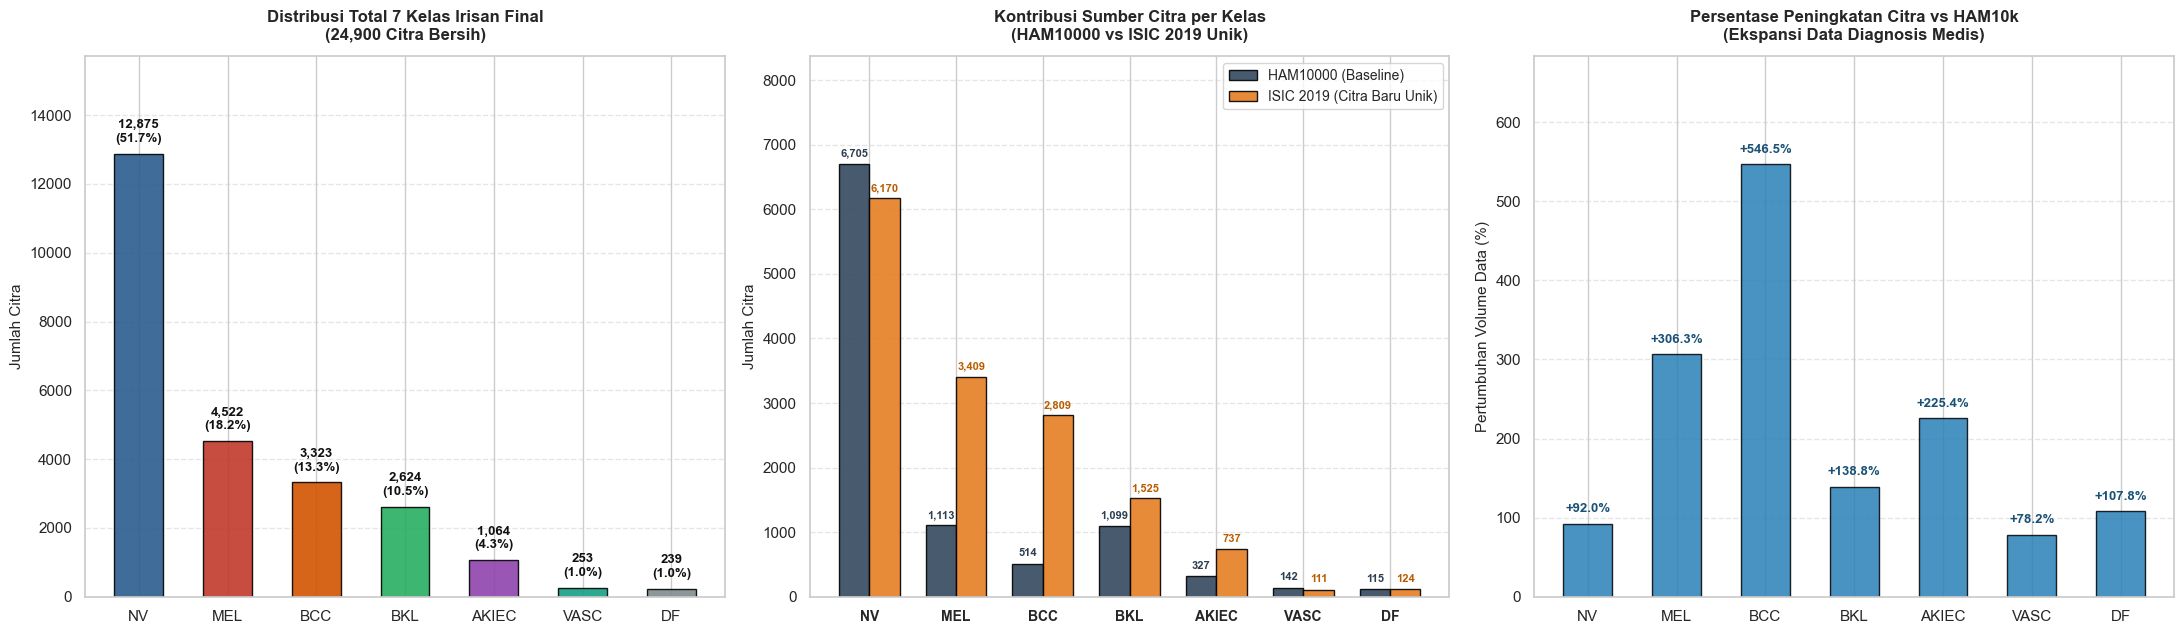

In [8]:
# 2. Visualisasi Grafik Batang Komparatif & Distribusi 7 Kelas
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))

codes = ['NV', 'MEL', 'BCC', 'BKL', 'AKIEC', 'VASC', 'DF']
colors_7 = ['#2b5c8f', '#c0392b', '#d35400', '#27ae60', '#8e44ad', '#16a085', '#7f8c8d']

# --- Subplot 1: Total Distribusi 7 Kelas Final ---
ax1 = axes[0]
counts_all = [len(df_7kelas_final[df_7kelas_final['harmonized_label'] == c]) for c in codes]
bars1 = ax1.bar(codes, counts_all, color=colors_7, edgecolor='black', width=0.55, alpha=0.9)
ax1.set_title("Distribusi Total 7 Kelas Irisan Final\n(24,900 Citra Bersih)", fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel("Jumlah Citra", fontsize=11)
ax1.set_ylim(0, max(counts_all) * 1.22)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    h = bar.get_height()
    pct = (h / total_akhir) * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        h + (max(counts_all) * 0.02),
        f"{int(h):,}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#111111'
    )

# --- Subplot 2: Kontribusi Masing-Masing Sumber Dataset ---
ax2 = axes[1]
x = np.arange(len(codes))
width = 0.35

ham_vals = [len(df_7kelas_final[(df_7kelas_final['source'] == 'ham10000') & (df_7kelas_final['harmonized_label'] == c)]) for c in codes]
isic_vals = [len(df_7kelas_final[(df_7kelas_final['source'] == 'isic_2019_train') & (df_7kelas_final['harmonized_label'] == c)]) for c in codes]

rects_ham = ax2.bar(x - width/2, ham_vals, width, label='HAM10000 (Baseline)', color='#34495e', edgecolor='black', alpha=0.9)
rects_isic = ax2.bar(x + width/2, isic_vals, width, label='ISIC 2019 (Citra Baru Unik)', color='#e67e22', edgecolor='black', alpha=0.9)

ax2.set_title("Kontribusi Sumber Citra per Kelas\n(HAM10000 vs ISIC 2019 Unik)", fontsize=12, fontweight='bold', pad=12)
ax2.set_xticks(x)
ax2.set_xticklabels(codes, fontsize=10, fontweight='bold')
ax2.set_ylabel("Jumlah Citra", fontsize=11)
ax2.set_ylim(0, max(counts_all) * 0.65)
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for rect in rects_ham:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + 80, f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold', color='#2c3e50')

for rect in rects_isic:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + 80, f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold', color='#b95d00')

# --- Subplot 3: Lonjakan Volume Kanker Kritis ---
ax3 = axes[2]
growth_pcts = [((counts_all[i] - ham_vals[i]) / ham_vals[i] * 100) for i in range(len(codes))]
bars3 = ax3.bar(codes, growth_pcts, color='#2980b9', edgecolor='black', width=0.55, alpha=0.85)

ax3.set_title("Persentase Peningkatan Citra vs HAM10k\n(Ekspansi Data Diagnosis Medis)", fontsize=12, fontweight='bold', pad=12)
ax3.set_ylabel("Pertumbuhan Volume Data (%)", fontsize=11)
ax3.set_ylim(0, max(growth_pcts) * 1.25)
ax3.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars3:
    h = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2.0,
        h + (max(growth_pcts) * 0.02),
        f"+{h:.1f}%",
        ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#1a5276'
    )

plt.tight_layout()
plt.show()


## Langkah 8 — DATA SIAP (Ekspor Dataset Final Irisan 7 Kelas)
Menyimpan metadata final hasil irisan 7 kelas multiclass ke file CSV `dataset_irisan_7kelas_final.csv` di folder `Dataset/`.
Dataset ini 100% bersih dari duplikat, terverifikasi secara klinis, dan siap digunakan langsung pada tahap pemodelan deep learning.


In [9]:
# Simpan dataset final ke file CSV
output_csv = os.path.join(ROOT, 'dataset_irisan_7kelas_final.csv')
cols_export = [
    'image_id',
    'source',
    'original_label',
    'harmonized_label',
    'target_7class',
    'class_name',
    'filepath'
]

df_7kelas_final[cols_export].to_csv(output_csv, index=False)

print("=" * 70)
print("DATASET HASIL IRISAN 7 KELAS (STANDAR EMAS) BERHASIL DISIMPAN!")
print("=" * 70)
print(f"Lokasi File     : {output_csv}")
print(f"Ukuran File     : {os.path.getsize(output_csv) / (1024*1024):.2f} MB")
print(f"Total Baris     : {len(df_7kelas_final):,} citra")
print(f"Total Kolom     : {len(cols_export)} kolom ({', '.join(cols_export)})")
print(f"Daftar Kelas    : 0=AKIEC, 1=BCC, 2=BKL, 3=DF, 4=MEL, 5=NV, 6=VASC")
print("Status Pipeline : SELESAI 100% (DATA SIAP UNTUK MODELING)")
print("=" * 70)

print("\nContoh 10 Baris Pertama Dataset yang Disimpan:")
display(pd.read_csv(output_csv).head(10))


DATASET HASIL IRISAN 7 KELAS (STANDAR EMAS) BERHASIL DISIMPAN!
Lokasi File     : C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_irisan_7kelas_final.csv
Ukuran File     : 4.39 MB
Total Baris     : 24,900 citra
Total Kolom     : 7 kolom (image_id, source, original_label, harmonized_label, target_7class, class_name, filepath)
Daftar Kelas    : 0=AKIEC, 1=BCC, 2=BKL, 3=DF, 4=MEL, 5=NV, 6=VASC
Status Pipeline : SELESAI 100% (DATA SIAP UNTUK MODELING)

Contoh 10 Baris Pertama Dataset yang Disimpan:


,image_id,source,original_label,harmonized_label,target_7class,class_name,filepath
0,ISIC_0000000,isic_2019_train,nv,NV,5,Melanocytic Nevus,C:\Users\ARII\Downloads\Data Understanding Isi...
1,ISIC_0000001,isic_2019_train,nv,NV,5,Melanocytic Nevus,C:\Users\ARII\Downloads\Data Understanding Isi...
2,ISIC_0000002,isic_2019_train,mel,MEL,4,Melanoma,C:\Users\ARII\Downloads\Data Understanding Isi...
3,ISIC_0000003,isic_2019_train,nv,NV,5,Melanocytic Nevus,C:\Users\ARII\Downloads\Data Understanding Isi...
4,ISIC_0000004,isic_2019_train,mel,MEL,4,Melanoma,C:\Users\ARII\Downloads\Data Understanding Isi...
5,ISIC_0000006,isic_2019_train,nv,NV,5,Melanocytic Nevus,C:\Users\ARII\Downloads\Data Understanding Isi...
6,ISIC_0000007,isic_2019_train,nv,NV,5,Melanocytic Nevus,C:\Users\ARII\Downloads\Data Understanding Isi...
7,ISIC_0000008,isic_2019_train,nv,NV,5,Melanocytic Nevus,C:\Users\ARII\Downloads\Data Understanding Isi...
8,ISIC_0000009,isic_2019_train,nv,NV,5,Melanocytic Nevus,C:\Users\ARII\Downloads\Data Understanding Isi...
9,ISIC_0000010,isic_2019_train,nv,NV,5,Melanocytic Nevus,C:\Users\ARII\Downloads\Data Understanding Isi...
